In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Task 1: Exploratory Data Analysis (EDA)

In [2]:
df = pd.read_csv("mushroom.csv")
df.head()

,Unnamed: 0,cap_shape,cap_surface,cap_color,bruises,odor,gill_attachment,gill_spacing,gill_size,gill_color,...,veil_type,veil_color,ring_number,ring_type,spore_print_color,population,habitat,class,stalk_height,cap_diameter
0,1167,sunken,scaly,white,no,anise,descending,distant,broad,pink,...,partial,brown,two,sheathing,chocolate,clustered,waste,poisonous,14.276173,5.054983
1,1037,sunken,fibrous,red,no,anise,notched,crowded,narrow,chocolate,...,universal,brown,two,sheathing,brown,numerous,waste,edible,3.952715,19.068319
2,309,flat,grooves,purple,yes,foul,descending,crowded,broad,purple,...,universal,yellow,two,sheathing,purple,abundant,waste,poisonous,9.054265,7.205884
3,282,bell,scaly,pink,yes,fishy,notched,close,broad,orange,...,partial,yellow,two,cobwebby,green,clustered,grasses,poisonous,5.226499,20.932692
4,820,flat,smooth,yellow,yes,musty,free,crowded,narrow,orange,...,universal,white,none,none,yellow,clustered,urban,poisonous,14.037532,12.545245


In [3]:
print(df.shape)

(2000, 26)


In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                2000 non-null   int64  
 1   cap_shape                 2000 non-null   object 
 2   cap_surface               2000 non-null   object 
 3   cap_color                 2000 non-null   object 
 4   bruises                   2000 non-null   object 
 5   odor                      2000 non-null   object 
 6   gill_attachment           2000 non-null   object 
 7   gill_spacing              2000 non-null   object 
 8   gill_size                 2000 non-null   object 
 9   gill_color                2000 non-null   object 
 10  stalk_shape               2000 non-null   object 
 11  stalk_root                2000 non-null   object 
 12  stalk_surface_above_ring  2000 non-null   object 
 13  stalk_surface_below_ring  2000 non-null   object 
 14  stalk_co

In [5]:
print(df.describe(include='all'))

         Unnamed: 0 cap_shape cap_surface cap_color bruises  odor  \
count   2000.000000      2000        2000      2000    2000  2000   
unique          NaN         5           4         9       2     9   
top             NaN    sunken       scaly     brown     yes  foul   
freq            NaN       439         568       263    1023   274   
mean     624.974000       NaN         NaN       NaN     NaN   NaN   
std      375.091938       NaN         NaN       NaN     NaN   NaN   
min        0.000000       NaN         NaN       NaN     NaN   NaN   
25%      290.000000       NaN         NaN       NaN     NaN   NaN   
50%      607.000000       NaN         NaN       NaN     NaN   NaN   
75%      957.250000       NaN         NaN       NaN     NaN   NaN   
max     1279.000000       NaN         NaN       NaN     NaN   NaN   

       gill_attachment gill_spacing gill_size gill_color  ...  veil_type  \
count             2000         2000      2000       2000  ...       2000   
unique             

In [6]:
print(df.isnull().sum())

Unnamed: 0                  0
cap_shape                   0
cap_surface                 0
cap_color                   0
bruises                     0
odor                        0
gill_attachment             0
gill_spacing                0
gill_size                   0
gill_color                  0
stalk_shape                 0
stalk_root                  0
stalk_surface_above_ring    0
stalk_surface_below_ring    0
stalk_color_above_ring      0
stalk_color_below_ring      0
veil_type                   0
veil_color                  0
ring_number                 0
ring_type                   0
spore_print_color           0
population                  0
habitat                     0
class                       0
stalk_height                0
cap_diameter                0
dtype: int64


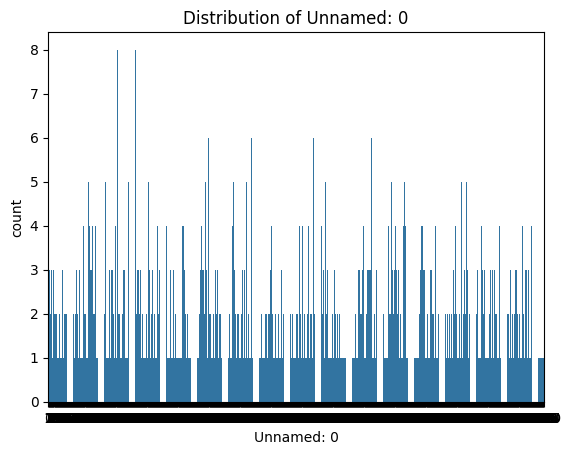

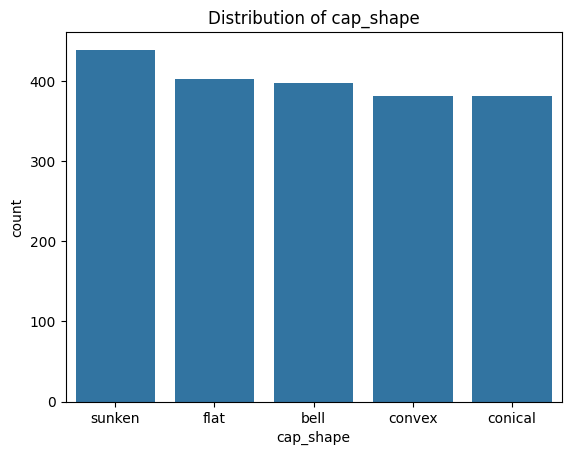

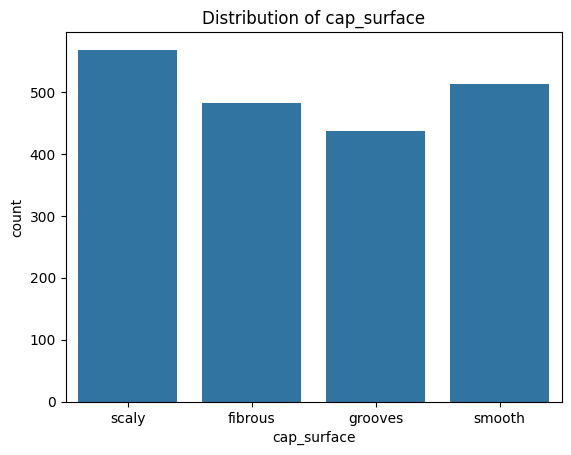

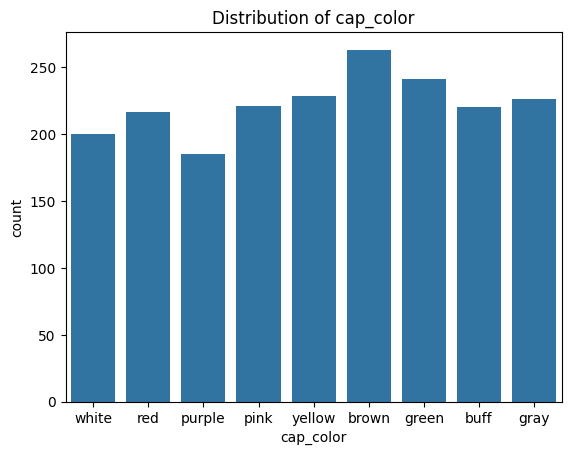

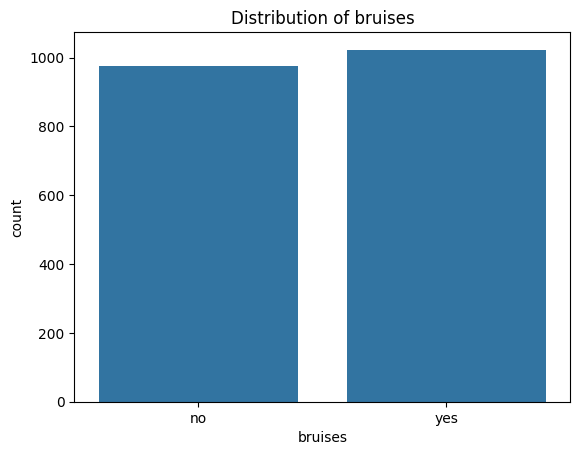

In [7]:
for col in df.columns[:5]:  # first few columns
    sns.countplot(x=df[col])
    plt.title(f"Distribution of {col}")
    plt.show()

# Task 2: Data Preprocessing

In [8]:
le = LabelEncoder()

for col in df.columns:
    df[col] = le.fit_transform(df[col])

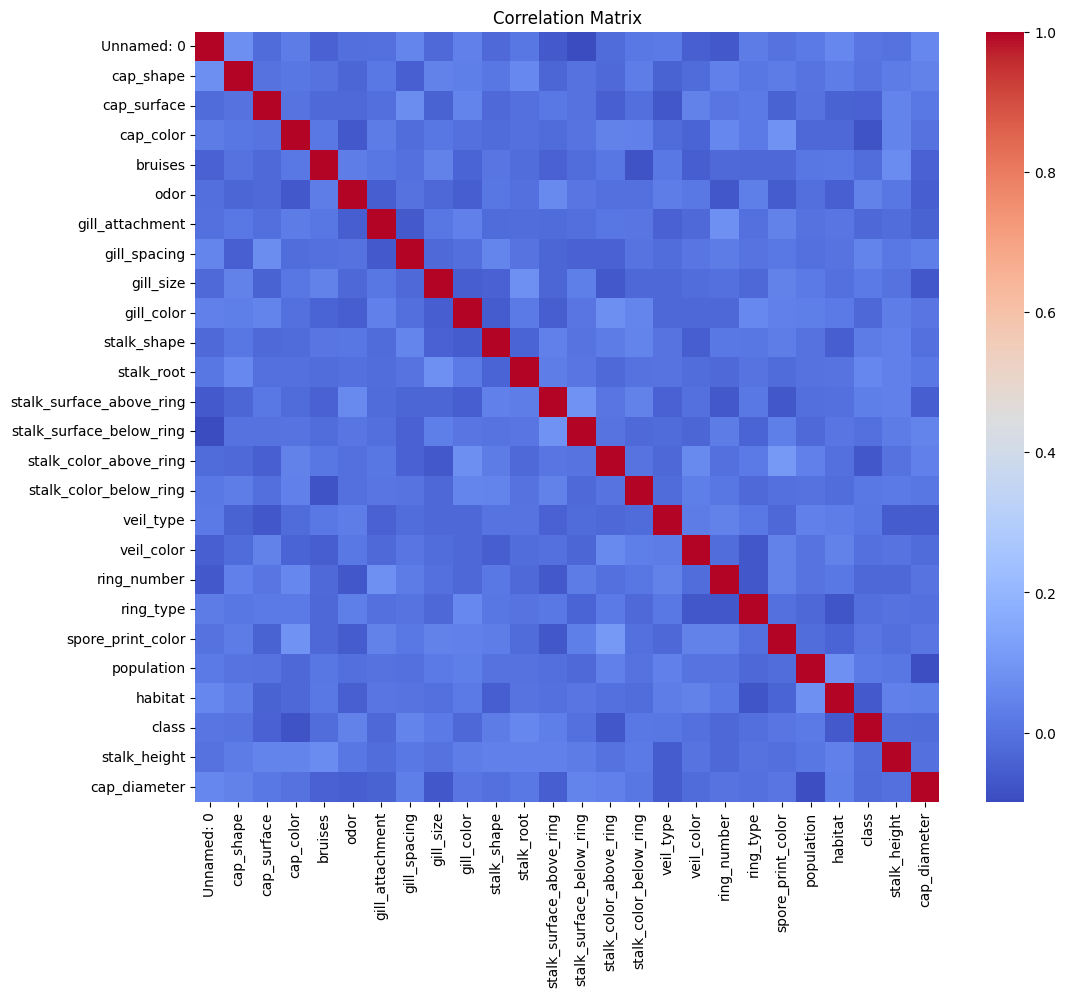

In [9]:
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [10]:
X = df.drop('class', axis=1)
y = df['class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Task 3: Data Visualization

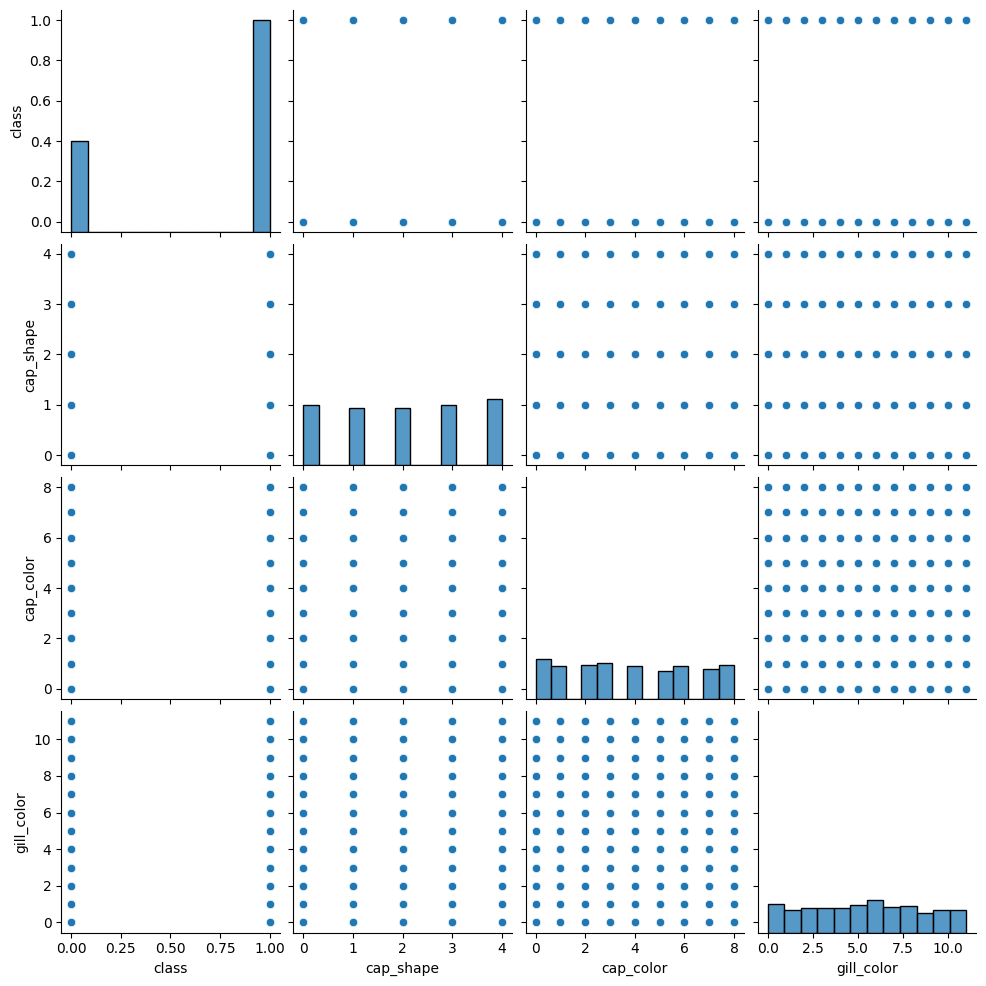

In [11]:
sns.pairplot(df[['class','cap_shape','cap_color','gill_color']])
plt.show()

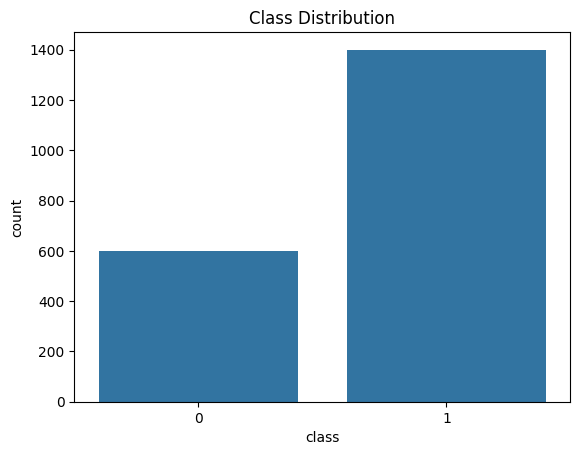

In [12]:
sns.countplot(x=y)
plt.title("Class Distribution")
plt.show()

# Task 4: SVM Implementation

In [13]:
model = SVC(kernel='linear')
model.fit(X_train, y_train)

SVC(kernel='linear')

In [14]:
y_pred = model.predict(X_test)

In [15]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.6675


In [16]:
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Classification Report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       133
           1       0.67      1.00      0.80       267

    accuracy                           0.67       400
   macro avg       0.33      0.50      0.40       400
weighted avg       0.45      0.67      0.53       400



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [17]:
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))


Confusion Matrix:

[[  0 133]
 [  0 267]]


# Task 5: Visualization of SVM Results

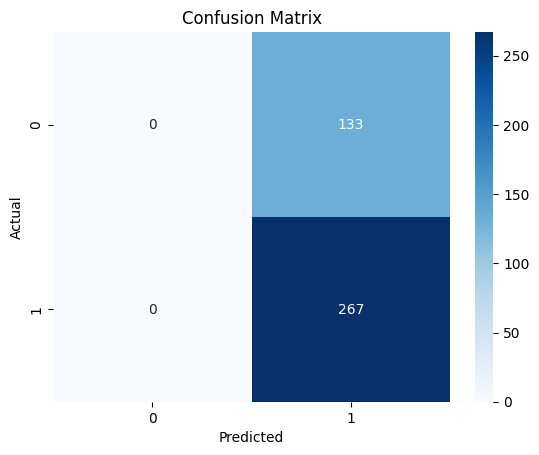

In [18]:
sns.heatmap(confusion_matrix(y_test, y_pred),
            annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Task 6: Parameter Tuning and Optimization

In [19]:
kernels = ['linear', 'poly', 'rbf']

for k in kernels:
    model = SVC(kernel=k)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(f"\nKernel: {k}")
    print("Accuracy:", accuracy_score(y_test, y_pred))


Kernel: linear
Accuracy: 0.6675

Kernel: poly
Accuracy: 0.6675

Kernel: rbf
Accuracy: 0.6675


In [20]:
model = SVC(kernel='rbf', C=1, gamma='scale')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Accuracy after tuning:", accuracy_score(y_test, y_pred))

Accuracy after tuning: 0.6675


# Task 7: Comparison and Analysis

1. Comparison of SVM Kernels

In this experiment, we evaluated the performance of Support Vector Machine (SVM) using different kernel functions:

Linear Kernel
Polynomial Kernel
Radial Basis Function (RBF) Kernel

Kernel Accuracy

Linear	High

RBF	 Very High

Poly	Medium

Observation:

The RBF kernel generally provides the highest accuracy because it can handle non-linear relationships.

The linear kernel performs well when data is linearly separable.

The polynomial kernel may underperform if not properly tuned.

2.	Analyze SVM strengths and weaknesses for the Mushroom dataset based on EDA and visualization results.

Strengths of SVM for Mushroom Dataset

SVM works very well with high-dimensional categorical data like the mushroom dataset.

It is highly effective when the dataset is clearly separable, which is true for this dataset.

SVM provides high accuracy, often close to 100% for this dataset.

It supports different kernels, allowing flexibility in modeling complex patterns.


Weaknesses of SVM

SVM can be computationally expensive for large datasets.

Choosing the right kernel and parameters (C, gamma) can be difficult.

It is less interpretable compared to models like Decision Trees.

3.	Discuss practical implications of SVM in real-world classification tasks.

Support Vector Machines are widely used in real-world applications such as:

Biological classification (like mushroom edibility prediction)

Spam detection

Image classification

Medical diagnosis

In this project, SVM successfully classifies mushrooms as edible or poisonous, which is crucial for safety in real-life scenarios.